# Figure 7 | T5 SHAP analysis

使用模型比较中 R² 最高的 XGBoost（nested-CV R² = 0.7071）进行全数据重训和描述性 SHAP 解释。

## 1. Parameters and imports

修改本节的 `PLOT`、`SUMMARY_PLOT` 或 `TOP_DEPENDENCE_FEATURES` 后，依次运行所有单元。

In [ ]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
import shap
from xgboost import XGBRegressor

TASK = 'T5'
BEST_MODEL = 'XGBoost'
RANDOM_STATE = 48
N_JOBS = 4
TOP_GLOBAL_FEATURES = 20
TOP_DEPENDENCE_FEATURES = 4

PLOT = {
    'axis_width_in': 6.5, 'axis_height_in': 5.2,
    'left_margin_in': 1.35, 'bottom_margin_in': 0.85,
    'right_margin_in': 0.35, 'top_margin_in': 0.45,
    'axis_label_size': 25, 'tick_label_size': 20,
    'spine_width': 2.8, 'tick_width': 1.8, 'tick_length': 6,
    'dot_size': 26, 'alpha': 1.0, 'transparent_background': True,
    'vector_formats': ('svg',),
}
SUMMARY_PLOT = {
    'max_display': 20, 'width_in': 6.0, 'base_height_in': 5.0,
    'height_per_feature_in': 0.35, 'title': '', 'title_size': 20,
    'x_label': 'SHAP value', 'axis_label_size': 20, 'tick_label_size': 15,
    'feature_to_plot_gap_in': 0.25, 'font_weight': 'bold',
    'tick_width': 2.5, 'tick_length': 6, 'point_size': 16, 'point_alpha': 1.0,
    'show_colorbar': True, 'colorbar_label': 'Feature Value',
    'colorbar_position': [0.875, 0.09, 0.028, 0.88],
    'feature_value_position': [0.955, 0.50], 'high_position': [0.9, 0.955],
    'low_position': [0.9, 0.1], 'colorbar_label_size': 16, 'high_low_size': 15,
    'transparent_background': True, 'vector_formats': ('svg',), 'spine_width': 1.2,
}

for path in (Path('/mnt/c/Windows/Fonts/arial.ttf'), Path('/mnt/c/Windows/Fonts/arialbd.ttf')):
    if not path.is_file():
        raise FileNotFoundError(f'Arial font file not found: {path}')
    font_manager.fontManager.addfont(str(path))
matplotlib.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'path', 'pdf.fonttype': 42})

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((item for item in (cwd, *cwd.parents) if (item / 'LCMWR').is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError(f'Cannot locate YYJ project root from: {cwd}')
MODEL_DIR = PROJECT_ROOT / 'LCMWR' / 'results' / 'model_compare' / TASK
OUTPUT_DIR = PROJECT_ROOT / 'LCMWR' / 'results' / 'interpretability' / TASK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

## 2. Load final features and refit the selected model

In [2]:
run_config = json.loads((MODEL_DIR / 'run_config.json').read_text(encoding='utf-8'))
all_best_params = json.loads((MODEL_DIR / 'best_params.json').read_text(encoding='utf-8'))
performance = pd.read_csv(MODEL_DIR / 'model_performance_summary.csv', encoding='utf-8-sig')
record = all_best_params[BEST_MODEL]
assert record['status'] == 'success', f'{BEST_MODEL} has no successful tuning record.'
params = {key.removeprefix('model__'): value for key, value in record['best_params'].items()}
metrics = performance.loc[performance['model'].eq(BEST_MODEL)].iloc[0].to_dict()

feature_path = Path(run_config['input_signature']['feature_matrix_path']['path'])
target_path = Path(run_config['resolved_input'])
target_column = run_config['target_column']
X = pd.read_csv(feature_path).astype(np.float32)
y = pd.read_csv(target_path, usecols=[target_column])[target_column].astype(np.float32)
assert X.columns.tolist() == run_config['feature_columns']
assert len(X) == len(y) and not X.isna().any().any() and not y.isna().any()

model = XGBRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=0, objective='reg:squarederror', tree_method='hist', **params)
X_model = X.to_numpy(dtype=np.float32, copy=False)
model.fit(X_model, y.to_numpy(dtype=np.float32, copy=False))
print(f'Loaded {X.shape[0]} samples × {X.shape[1]} features')
print('Nested-CV {} R²: {:.4f} ± {:.4f}'.format(BEST_MODEL, metrics['R2_mean'], metrics['R2_std']))

Loaded 584 samples × 582 features
Nested-CV XGBoost R²: 0.7069 ± 0.0766


## 3. Calculate SHAP and export vector plots

In [3]:
shap_values = np.asarray(shap.TreeExplainer(model).shap_values(X_model, check_additivity=False))
assert shap_values.shape == X.shape

RDLogger.DisableLog('rdApp.error')
def display_name(feature):
    molecule = Chem.MolFromSmiles(feature)
    return Chem.MolToSmiles(molecule) if molecule is not None else feature

display_names = [display_name(name) for name in X.columns]
ranking = pd.DataFrame({'feature': X.columns, 'display_feature': display_names, 'mean_abs_shap': np.abs(shap_values).mean(axis=0), 'mean_shap': shap_values.mean(axis=0)}).sort_values('mean_abs_shap', ascending=False, kind='stable').reset_index(drop=True)
ranking.insert(0, 'shap_rank', np.arange(1, len(ranking) + 1))

n_show = min(SUMMARY_PLOT['max_display'], X.shape[1])
fig = plt.figure(figsize=(SUMMARY_PLOT['width_in'], max(SUMMARY_PLOT['base_height_in'], SUMMARY_PLOT['height_per_feature_in'] * n_show + 1.8)))
shap.summary_plot(shap_values, X, feature_names=display_names, max_display=n_show, plot_size=None, show=False, alpha=SUMMARY_PLOT['point_alpha'], color_bar=SUMMARY_PLOT['show_colorbar'], color_bar_label=SUMMARY_PLOT['colorbar_label'])
ax = plt.gca()
if SUMMARY_PLOT['transparent_background']:
    fig.patch.set_alpha(0); ax.set_facecolor('none')
for collection in ax.collections:
    collection.set_sizes([SUMMARY_PLOT['point_size']])
ax.set_title(SUMMARY_PLOT['title'], fontsize=SUMMARY_PLOT['title_size'], fontweight=SUMMARY_PLOT['font_weight'])
ax.set_xlabel(SUMMARY_PLOT['x_label'], fontsize=SUMMARY_PLOT['axis_label_size'], fontweight=SUMMARY_PLOT['font_weight'])
ax.tick_params(axis='both', labelsize=SUMMARY_PLOT['tick_label_size'], width=SUMMARY_PLOT['tick_width'], length=SUMMARY_PLOT['tick_length'])
for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]: label.set_fontweight(SUMMARY_PLOT['font_weight'])
for spine in ax.spines.values(): spine.set_linewidth(SUMMARY_PLOT['spine_width'])
ax.spines['bottom'].set_linewidth(SUMMARY_PLOT['tick_width'])
plt.tight_layout()
for suffix in SUMMARY_PLOT['vector_formats']:
    fig.savefig(OUTPUT_DIR / f'shap_summary_plot_{TASK}.{suffix}', bbox_inches='tight', transparent=SUMMARY_PLOT['transparent_background'])
plt.close(fig)

def safe_stem(rank, feature):
    safe_feature = re.sub(r'[^A-Za-z0-9]+', '_', feature).strip('_')
    return 'shap_dependence_{:02d}_{}_{}'.format(rank, safe_feature, TASK)

outputs = []
for rank, feature in enumerate(ranking.head(TOP_DEPENDENCE_FEATURES)['feature'], start=1):
    figure_width = PLOT['left_margin_in'] + PLOT['axis_width_in'] + PLOT['right_margin_in']
    figure_height = PLOT['bottom_margin_in'] + PLOT['axis_height_in'] + PLOT['top_margin_in']
    fig = plt.figure(figsize=(figure_width, figure_height))
    ax = fig.add_axes([PLOT['left_margin_in'] / figure_width, PLOT['bottom_margin_in'] / figure_height, PLOT['axis_width_in'] / figure_width, PLOT['axis_height_in'] / figure_height])
    if PLOT['transparent_background']:
        fig.patch.set_alpha(0); ax.set_facecolor('none')
    shap.dependence_plot(X.columns.get_loc(feature), shap_values, X, feature_names=display_names, interaction_index='auto', ax=ax, show=False, dot_size=PLOT['dot_size'], alpha=PLOT['alpha'])
    for extra_axis in list(fig.axes):
        if extra_axis is not ax: extra_axis.remove()
    ax.set_title(''); ax.set_ylabel('SHAP Value', fontsize=PLOT['axis_label_size'], fontweight='bold')
    ax.xaxis.label.set_fontsize(PLOT['axis_label_size']); ax.xaxis.label.set_fontweight('bold')
    ax.tick_params(axis='both', labelsize=PLOT['tick_label_size'], width=PLOT['tick_width'], length=PLOT['tick_length'])
    for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]: label.set_fontweight('bold')
    for spine in ax.spines.values(): spine.set_visible(True); spine.set_linewidth(PLOT['spine_width'])
    stem = safe_stem(rank, feature)
    for suffix in PLOT['vector_formats']:
        fig.savefig(OUTPUT_DIR / f'{stem}.{suffix}', transparent=PLOT['transparent_background'])
    plt.close(fig)
    outputs.append({'rank': rank, 'feature': feature, 'display_feature': display_name(feature), 'svg': f'{stem}.svg'})

np.save(OUTPUT_DIR / f'shap_values_{TASK}.npy', shap_values)
pd.DataFrame(shap_values, columns=X.columns).to_csv(OUTPUT_DIR / f'shap_values_{TASK}.csv', index=False)
ranking.to_csv(OUTPUT_DIR / f'shap_importance_ranking_{TASK}.csv', index=False)
pd.DataFrame(outputs).to_csv(OUTPUT_DIR / f'shap_dependence_plot_files_{TASK}.csv', index=False)
metadata = {'created_at_utc': datetime.now(timezone.utc).isoformat(), 'task': TASK, 'model': 'XGBRegressor', 'tuned_model_parameters': params, 'nested_cv_performance': metrics, 'explanation_scope': 'Full-data refit; descriptive SHAP, not OOF-SHAP.'}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print(ranking.head(TOP_DEPENDENCE_FEATURES)[['shap_rank', 'feature', 'display_feature', 'mean_abs_shap']].to_string(index=False))

 shap_rank                    feature      display_feature  mean_abs_shap
         1           CCC1=CC=C(C)C=C1        CCc1ccc(C)cc1       7.272404
         2             O=CC1=CC=CC=C1          O=Cc1ccccc1       6.261528
         3 CC1=CC=C(OC2=CC=CC=C2)C=C1 Cc1ccc(Oc2ccccc2)cc1       4.618269
         4   C1=CC=C(C2=CC=CC=C2)C=C1  c1ccc(-c2ccccc2)cc1       4.162679


## 4. Publication style override

使用 LOI/Tg 的 Figure 5 版式覆盖同名 SVG；仅改变显示样式，不改变已计算的 SHAP 数值与特征排序。

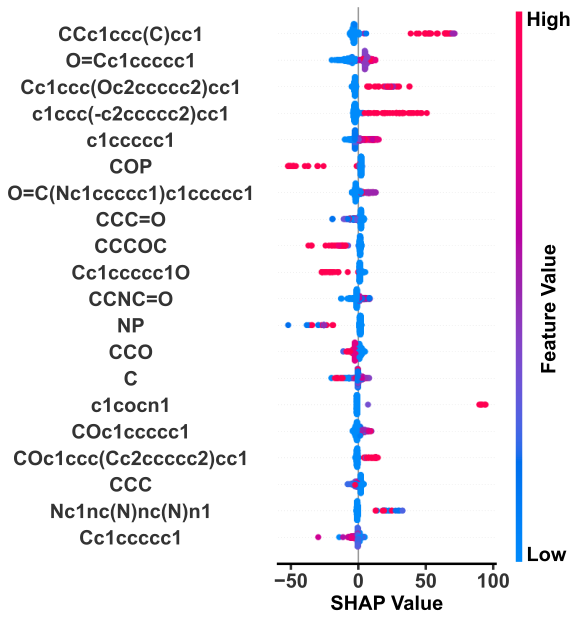

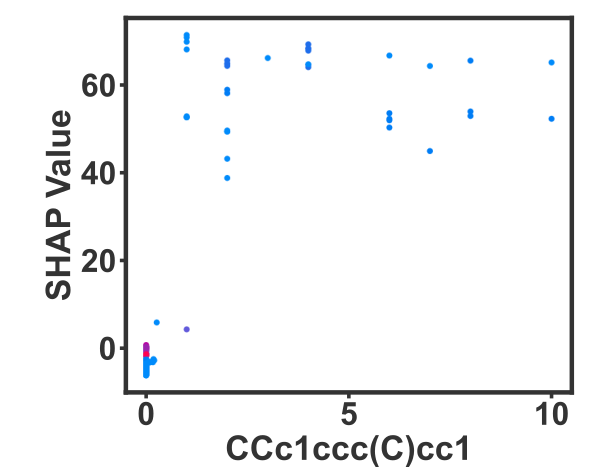

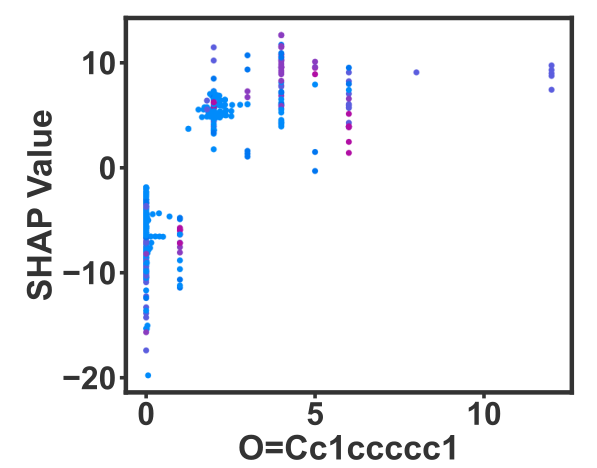

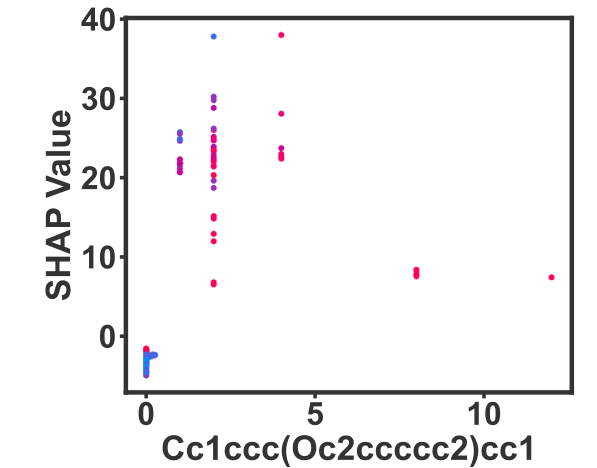

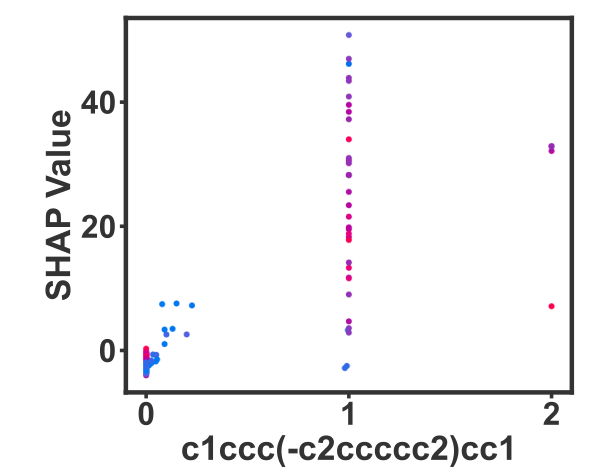

,rank,feature,display_feature,svg
0,1,CCC1=CC=C(C)C=C1,CCc1ccc(C)cc1,shap_dependence_01_CCC1_CC_C_C_C_C1_T5.svg
1,2,O=CC1=CC=CC=C1,O=Cc1ccccc1,shap_dependence_02_O_CC1_CC_CC_C1_T5.svg
2,3,CC1=CC=C(OC2=CC=CC=C2)C=C1,Cc1ccc(Oc2ccccc2)cc1,shap_dependence_03_CC1_CC_C_OC2_CC_CC_C2_C_C1_...
3,4,C1=CC=C(C2=CC=CC=C2)C=C1,c1ccc(-c2ccccc2)cc1,shap_dependence_04_C1_CC_C_C2_CC_CC_C2_C_C1_T5...


In [4]:
import sys
from IPython.display import SVG, display

SHAP_SCRIPT_DIR = PROJECT_ROOT / 'LCMWR' / 'scripts' / 'shap_analysis'
if str(SHAP_SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SHAP_SCRIPT_DIR))
from publication_shap_style import export_publication_shap_plots

# ===== Figure 5 样式参数：可直接修改 =====
PUBLICATION_PLOT = {
    'axis_width_in': 6.2, 'axis_height_in': 5.2,
    'left_margin_in': 1.75, 'bottom_margin_in': 1.05,
    'right_margin_in': 0.35, 'top_margin_in': 0.25,
    'axis_label_size': 34, 'y_axis_label_size': 34, 'tick_label_size': 32,
    'font_weight': 'bold', 'spine_width': 4.5, 'tick_width': 3.6, 'tick_length': 6,
    'dot_size': 36, 'alpha': 1.0, 'transparent_background': True,
}
PUBLICATION_SUMMARY = {
    'max_display': 20, 'width_in': 6.0, 'base_height_in': 5.0,
    'height_per_feature_in': 0.35, 'height_padding_in': 1.8,
    'axis_label_size': 20, 'tick_label_size': 20,
    'feature_to_plot_gap_in': 0.25, 'feature_label_alignment': 'center',
    'tick_width': 2.5, 'tick_length': 6, 'spine_width': 1.2,
    'point_size': 36, 'point_alpha': 1.0, 'show_colorbar': True,
    'colorbar_label': 'Feature Value',
    'colorbar_position': [0.875, 0.10, 0.028, 0.87],
    'feature_value_position': [0.955, 0.50],
    'high_position': [0.90, 0.955], 'low_position': [0.90, 0.11],
    'colorbar_label_size': 20, 'high_low_size': 20,
    'transparent_background': True,
}
SUMMARY_X_TICK_INTERVAL = 50  # T5 summary 的 SHAP Value 横轴主刻度间距

summary_svg, publication_outputs = export_publication_shap_plots(
    task=TASK, output_dir=OUTPUT_DIR, features=X, shap_values=shap_values,
    ranking=ranking, display_names=display_names, summary_x_label='SHAP Value',
    summary_tick_interval=SUMMARY_X_TICK_INTERVAL,
    dependence_count=TOP_DEPENDENCE_FEATURES, plot=PUBLICATION_PLOT,
    summary=PUBLICATION_SUMMARY,
)
publication_outputs.to_csv(OUTPUT_DIR / f'shap_dependence_plot_files_{TASK}.csv', index=False)
display(SVG(filename=str(summary_svg)))
for svg_name in publication_outputs['svg']:
    display(SVG(filename=str(OUTPUT_DIR / svg_name)))
display(publication_outputs)
